In [27]:
import pandas as pd
import numpy as np
from google.colab import drive
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.utils import class_weight

In [28]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
path = '/content/drive/My Drive/hate_comments_reduced.npz'
data = np.load(path)
X = data['X']
y = data['y']

In [30]:
print(X)
print(y)

[[ 1.52713170e-01  7.87195078e-02  3.86308454e-02 ... -3.75138592e-02
   7.75090662e-03 -1.50532093e-02]
 [ 9.03135763e-02 -1.32459492e-02  1.17142533e-01 ...  1.47882293e-02
   1.23907025e-02  6.61762260e-03]
 [ 2.62973742e-01  1.37287595e-01  2.21852112e-02 ... -1.65928802e-02
  -1.08460444e-02  2.64032435e-02]
 ...
 [ 3.16356505e-02 -1.04318285e-02 -3.82143897e-03 ... -2.58740995e-04
   5.95751426e-02 -4.74302850e-02]
 [ 2.20027206e-02 -4.99205002e-03 -1.54322368e-02 ... -1.23317720e-02
   7.81384498e-03 -1.55986807e-02]
 [ 1.41907041e-02 -9.84351892e-03 -4.07038702e-03 ... -8.81532728e-05
   1.01253632e-03 -7.77042686e-04]]
[4 4 4 ... 4 4 4]


In [31]:
X.shape

(223113, 300)

In [47]:
unique_values , counts = np.unique(y,return_counts =True)
print(unique_values)
print(counts)
len(unique_values)
# Highly Imbalanced Data

[0 1 2 3 4]
[    68    397    588     31 222029]


5

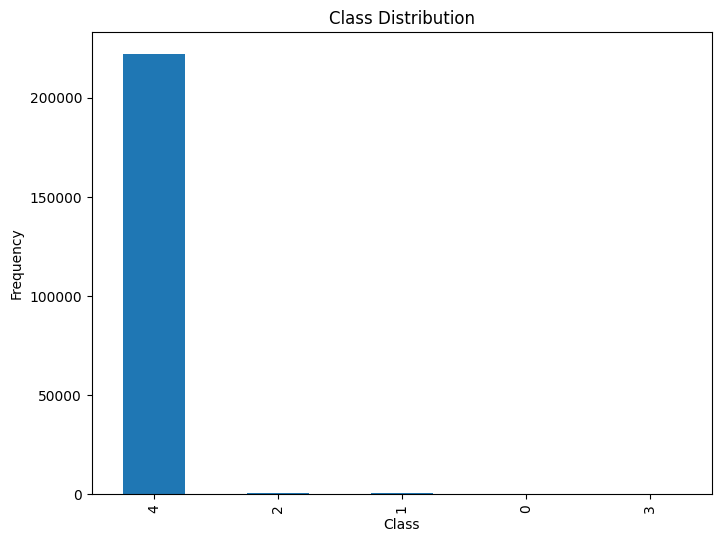

In [33]:
plt.figure(figsize=(8, 6))
pd.Series(y).value_counts().plot(kind='bar', title='Class Distribution')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()

In [34]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [35]:
weights = class_weight.compute_class_weight('balanced',classes = np.unique(y_train), y = y_train)
class_weights = dict(enumerate(weights))

In [36]:
import tensorflow as tf
import keras
from keras import layers

In [48]:
inputs = keras.Input(shape = (300,))
x = layers.Dense(128,activation = 'relu')(inputs)
x = layers.Dense(64, activation= 'relu')(inputs)
outputs = layers.Dense(5,activation= 'softmax')(x)
model = keras.Model(inputs = inputs, outputs = outputs)

In [49]:
model.compile(optimizer= keras.optimizers.Adam(learning_rate = 1e-3),loss = keras.losses.SparseCategoricalCrossentropy(),metrics = [keras.metrics.SparseCategoricalAccuracy()])

In [60]:
history = model.fit(X_train,y_train,epochs= 50,class_weight=class_weights,batch_size = 32)

Epoch 1/50
5578/5578 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.1179 - sparse_categorical_accuracy: 0.9088
Epoch 2/50
5578/5578 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.1132 - sparse_categorical_accuracy: 0.9000
Epoch 3/50
5578/5578 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.1126 - sparse_categorical_accuracy: 0.9097
Epoch 4/50
5578/5578 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 0.1062 - sparse_categorical_accuracy: 0.9110
Epoch 5/50
5578/5578 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.1043 - sparse_categorical_accuracy: 0.9087
Epoch 6/50
5578/5578 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.1150 - sparse_categorical_accuracy: 0.9137
Epoch 7/50
5578/5578 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 0.0866 - sparse_categorical_accuracy: 0.9199
Epoch 8/50
5578/5578 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.0974 - sparse_categorical_accuracy: 0.9145
Epoch 9/50
5578/5578 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - loss: 0.1058 - sparse_categorical_accuracy: 0.9190
Epoch 10/50
5578/5578 ━━━━━━

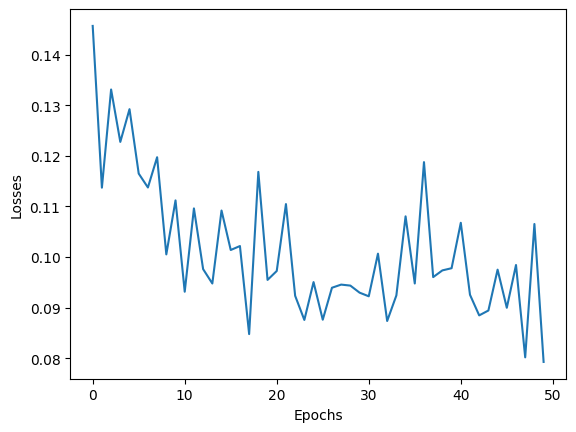

In [61]:
losses=history.history['loss']
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.show()

In [64]:
print("Evaluate on test data")
results = model.evaluate(X_test, y_test, batch_size=128)
print(f"test loss:{results[0]}, test acc:{results[1]}")

Evaluate on test data
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2601 - sparse_categorical_accuracy: 0.9322
test loss:0.25954052805900574, test acc:0.9319857358932495


In [68]:
from sklearn.metrics import precision_score,average_precision_score, recall_score
predictions_proba = model.predict(X_test)
predictions = np.argmax(predictions_proba,axis =1)
print(f"Precision : {precision_score(y_test,predictions,average='weighted')}, PR_AUC : {average_precision_score(y_test,predictions_proba,average='weighted')},Recall score:{recall_score(y_test,predictions,average='weighted')}")

1395/1395 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Precision : 0.9914931686781034, ROC_AUC : 0.9932876953546486,Recall score:0.9319857472603814
